# Player trajectory forecasting: model reproduction, diversity, and scored frontier

**Snapshot: September 23, 2026 UTC.** Alvaro Mendizabal.

This notebook is the public evidence layer for the current deep-model research program. It uses aggregate receipts only: no raw tracking data, player identities, credentials, or trained weights are required.

## Architecture and base reproduction

The reproduced base family uses 20 observed frames, 10 dynamic channels, 12 static channels, grouped temporal convolutions, cross-player attention, trajectory decoding, Gaussian objectives, and EMA inference. Five game-grouped folds produce 561,607 excluded-fold rows. The complete first-place 100+ model ensemble is **not** reproduced.

In [1]:
import json, math, io, base64
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
E=json.loads(Path('research/evidence/model_reproduction.json').read_text())
def show(fig, static, name, height=480):
    fig.update_layout(width=920,height=height,margin=dict(l=90,r=40,t=80,b=80),font=dict(size=14))
    static.set_size_inches(9.2,height/100);static.tight_layout()
    buf=io.BytesIO();static.savefig(buf,format='png',dpi=120)
    Path('research/figures').mkdir(exist_ok=True)
    Path('research/figures/'+name+'.png').write_bytes(buf.getvalue())
    display({'application/vnd.plotly.v1+json':json.loads(fig.to_json()),'image/png':base64.b64encode(buf.getvalue()).decode()},raw=True)
    plt.close(static)
n=sum(f['rows'] for f in E['base_folds'])
r=math.sqrt(sum(f['rows']*f['rmse']**2 for f in E['base_folds'])/n)
assert n==561607 and abs(r-E['base_oof_rmse'])<1e-12
print(f'Base family: {r:.9f} coordinate RMSE over {n:,} excluded-fold rows.')
print(f"Latest private score: {E['current_private_score']:.5f}; final first-place private: {E['first_place_private_score']:.5f}.")


Base family: 0.468143852 coordinate RMSE over 561,607 excluded-fold rows.
Latest private score: 0.46547; final first-place private: 0.46340.


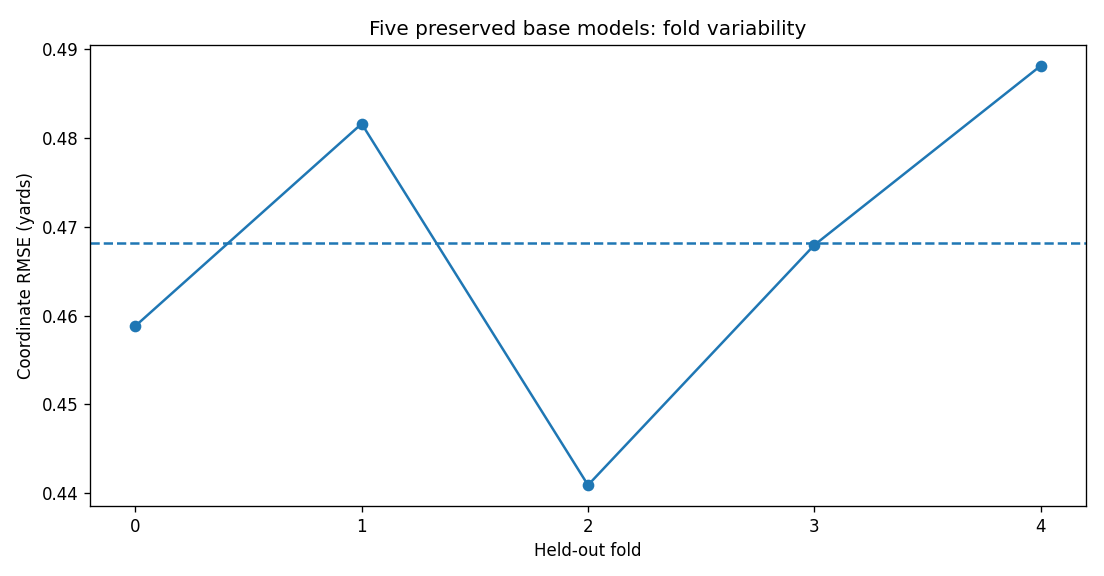

In [2]:
f=E['base_folds']; x=[str(v['fold']) for v in f]; y=[v['rmse'] for v in f]
fig=go.Figure(go.Scatter(x=x,y=y,mode='markers+lines',name='Excluded-fold base',text=[str(v['rows'])+' rows' for v in f]))
fig.update_layout(title='Five preserved base models: game-grouped fold variability',xaxis_title='Held-out fold',yaxis_title='Coordinate RMSE (yards; lower is better)')
fig.add_hline(y=E['base_oof_rmse'],line_dash='dash',annotation_text='Pooled OOF')
static,ax=plt.subplots();ax.plot(x,y,marker='o');ax.axhline(E['base_oof_rmse'],linestyle='--');ax.set(xlabel='Held-out fold',ylabel='Coordinate RMSE (yards)',title='Five preserved base models: fold variability')
show(fig,static,'winner_folds')


Fold variation is substantial, so pooled OOF is computed from row-weighted squared errors before taking the square root. Checkpoints were selected on these folds; this is model-selection evidence, not an untouched final assessment.

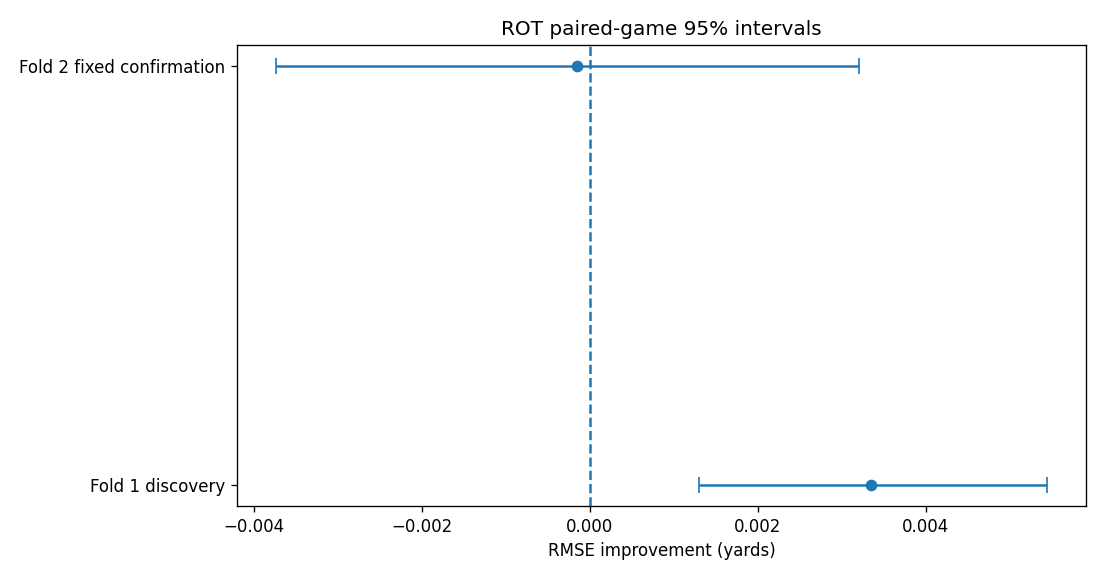

In [3]:
trials=E['rot']; labels=[t['stage'] for t in trials]; gains=[t['gain'] for t in trials]
low=[t['gain']-t['interval95'][0] for t in trials];high=[t['interval95'][1]-t['gain'] for t in trials]
fig=go.Figure(go.Scatter(x=gains,y=labels,mode='markers',error_x=dict(type='data',array=high,arrayminus=low,symmetric=False)))
fig.update_layout(title='ROT geometry: discovery did not replicate',xaxis_title='Base RMSE minus blend RMSE (positive is better)',yaxis_title='Experiment')
fig.add_vline(x=0,line_dash='dash')
static,ax=plt.subplots();ax.errorbar(gains,labels,xerr=[low,high],fmt='o',capsize=5);ax.axvline(0,linestyle='--');ax.set(xlabel='RMSE improvement (yards)',title='ROT paired-game 95% intervals')
show(fig,static,'winner_confirmation')


ROT passed a Fold-1 discovery gate but failed the fixed Fold-2 confirmation. The negative result remains part of the research record and its threshold, epoch, and weight were not changed post hoc.

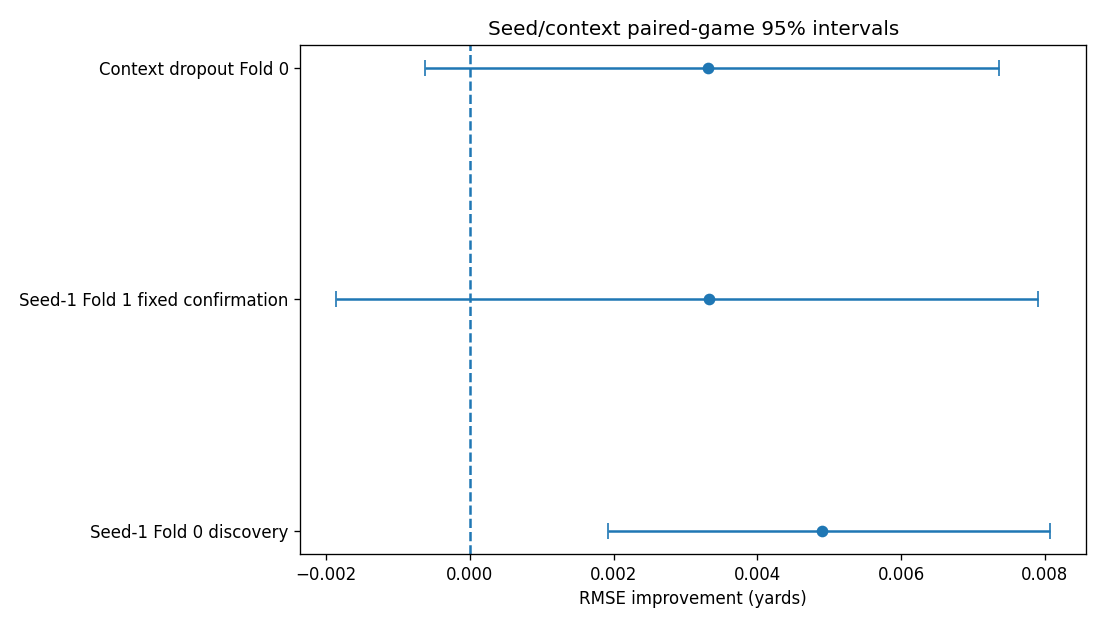

In [4]:
trials=E['seed_diversity']+[E['context_dropout']];labels=['Seed-1 '+t['stage'] for t in E['seed_diversity']]+['Context dropout Fold 0'];g=[t['gain'] for t in trials]
lo=[t['gain']-t['interval95'][0] for t in trials];hi=[t['interval95'][1]-t['gain'] for t in trials]
fig=go.Figure(go.Scatter(x=g,y=labels,mode='markers',error_x=dict(type='data',array=hi,arrayminus=lo,symmetric=False),text=[t['decision'] for t in trials]))
fig.update_layout(title='Diversity models: useful point gains, mixed confirmation strength',xaxis_title='Base RMSE minus fixed 50/50 blend RMSE',yaxis_title='Experiment')
fig.add_vline(x=0,line_dash='dash')
static,ax=plt.subplots();ax.errorbar(g,labels,xerr=[lo,hi],fmt='o',capsize=5);ax.axvline(0,linestyle='--');ax.set(xlabel='RMSE improvement (yards)',title='Seed/context paired-game 95% intervals')
show(fig,static,'winner_diversity',height=520)


Independent initialization and protected context dropout both produced complementary point gains. Seed-1 passed discovery but its fixed Fold-1 confirmation interval crossed zero. Context dropout also crossed zero on Fold 0. Neither was promoted as a standalone system; both were preserved as diversity candidates.

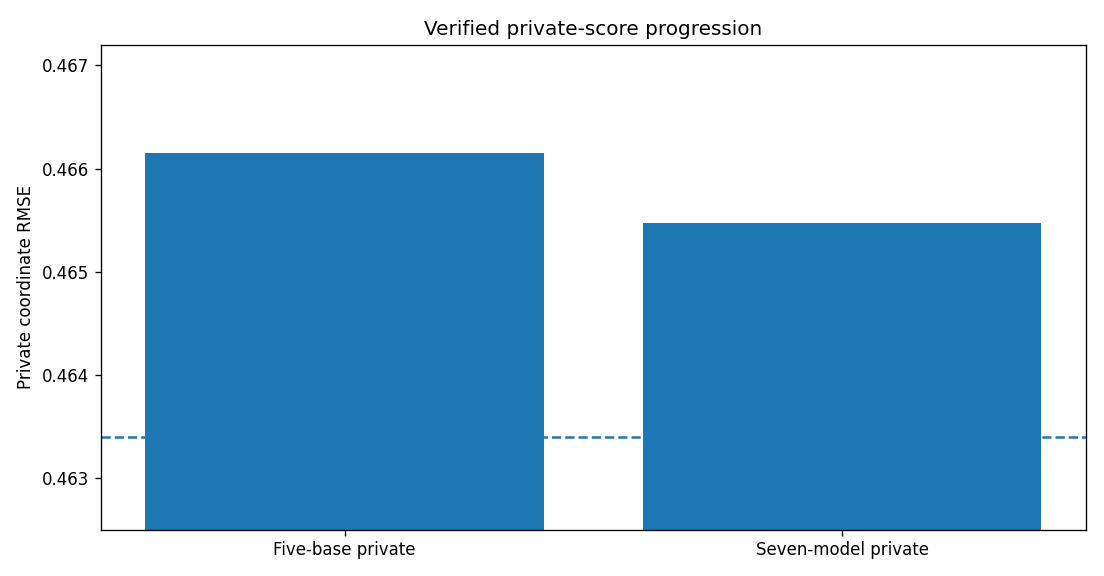

In [5]:
labels=['Five-base private','Seven-model private'];scores=[E['prior_private_score'],E['current_private_score']];target=E['first_place_private_score']
fig=go.Figure(go.Bar(x=labels,y=scores,text=[f'{v:.5f}' for v in scores],textposition='outside'))
fig.add_hline(y=target,line_dash='dash',annotation_text=f'First place {target:.5f}')
fig.update_layout(title='Verified private-score progression',xaxis_title='Scored system',yaxis_title='Private coordinate RMSE (lower is better)',yaxis_range=[0.4625,0.4672])
static,ax=plt.subplots();ax.bar(labels,scores);ax.axhline(target,linestyle='--');ax.set_ylim(.4625,.4672);ax.set(ylabel='Private coordinate RMSE',title='Verified private-score progression')
show(fig,static,'winner_private_score')


The fixed seven-model equal ensemble—five base models plus seed-1 Fold 0 and context-dropout Fold 0—was deployed without additional fitting. Its private RMSE improved **0.46615 → 0.46547**. The final first-place private score is **0.46340**, so the remaining comparable gap is **0.00207 (0.447%)**. This is a post-competition research comparison; no official rank is claimed.

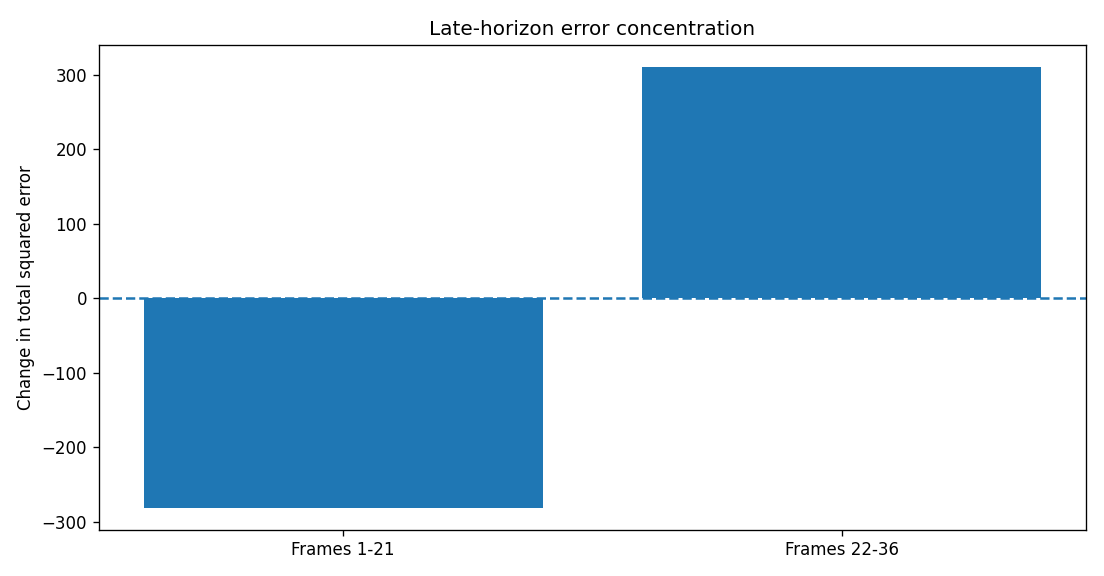

In [6]:
s=E['horizon_segments'];labels=[v['segment'] for v in s];delta=[v['delta_sse'] for v in s]
fig=go.Figure(go.Bar(x=labels,y=delta,text=[str(v['rows'])+' rows' for v in s]))
fig.update_layout(title='Fold 2 ROT confirmation: late horizons erased earlier gains',xaxis_title='Forecast segment',yaxis_title='Blend minus base total squared error')
static,ax=plt.subplots();ax.bar(labels,delta);ax.axhline(0,linestyle='--');ax.set(ylabel='Change in total squared error',title='Late-horizon error concentration')
show(fig,static,'winner_horizon')


## Current decision

The leaderboard gain demonstrates that diversity transferred, but the gap remains. The next experiment targets a larger missing winning-system capability: a complete second game-grouped cross-validation split family. That alternate-CV study is prepared but **pending user execution**; this notebook claims no alternate-CV metric.

AWS remains the private experiment system of record for raw competition data and weights. GitHub contains only selected source, aggregate evidence, executed notebooks, and documentation.

In [7]:
assert E['current_private_score']==0.46547
assert E['first_place_private_score']==0.4634
assert E['alternate_cv']['status']=='PENDING_USER_EXECUTION'
print('REVIEW_COMPLETE: five inline figures, aggregate arithmetic verified, scored seven-model frontier documented.')

REVIEW_COMPLETE: five inline figures, aggregate arithmetic verified, scored seven-model frontier documented.
